# 02 — Exploratory Data Analysis

Inspect the cleaned dataset:

1. Summary statistics.
2. Target distribution and skewness.
3. Feature distributions.
4. Pearson correlations vs. the target.
5. Scatterplots for the top-correlated features.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parents[1]
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

SCRATCH = REPO_ROOT / "notebooks" / "_artifacts"

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import config

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

df = pd.read_parquet(SCRATCH / "clean.parquet")
print(f"loaded {df.shape[0]:,} rows x {df.shape[1]} cols")

loaded 9,997 rows x 12 cols


## Summary statistics

In [2]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
price,9997.0,1.822073e+05,143122.060056,7021.00,113979.00,151026.00,209342.00,3662668.00
year,9997.0,2.002339e+03,1.532412,2000.00,2001.00,2002.00,2004.00,2005.00
age,9997.0,1.314054e+01,14.537376,0.00,0.00,9.00,21.00,101.00
beds,9997.0,3.366210e+00,0.769979,1.00,3.00,3.00,4.00,8.00
baths,9997.0,2.223067e+00,0.718984,1.00,2.00,2.00,2.50,9.00
home_size,9997.0,1.920099e+03,804.949814,506.00,1359.00,1751.00,2276.00,9474.00
parcel_size,9997.0,1.061968e+04,15558.768122,576.00,6466.00,8333.00,10973.00,620806.00
pool,9997.0,2.152646e-01,0.411026,0.00,0.00,0.00,0.00,1.00
dist_cbd,9997.0,1.450179e+04,6216.689132,551.46,9725.36,14856.87,19729.87,43342.66
dist_lakes,9997.0,1.480922e+03,1754.231451,4.52,331.50,707.73,1871.36,8203.53


## Target distribution

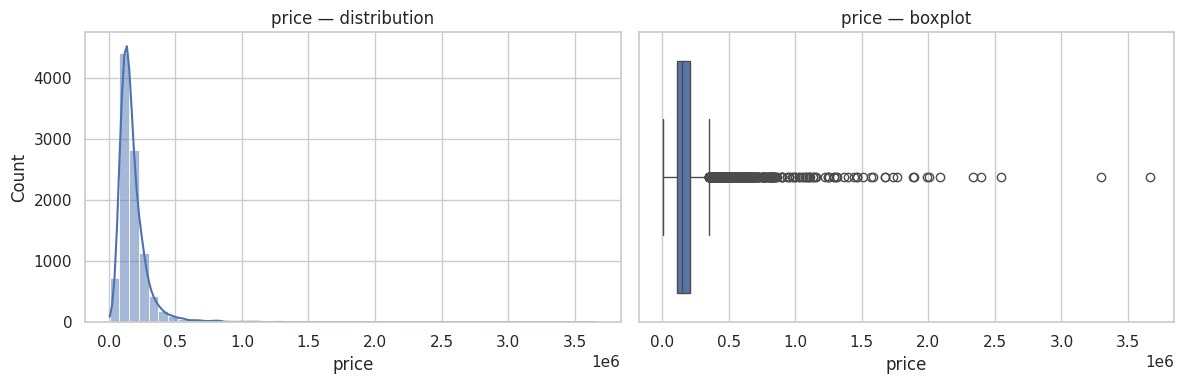

skewness: 7.360
min:      7,021
median:   151,026
max:      3,662,668


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df[config.TARGET], bins=50, kde=True, ax=axes[0])
axes[0].set_title(f"{config.TARGET} — distribution")
sns.boxplot(x=df[config.TARGET], ax=axes[1])
axes[1].set_title(f"{config.TARGET} — boxplot")
plt.tight_layout(); plt.show()

print(f"skewness: {df[config.TARGET].skew():.3f}")
print(f"min:      {df[config.TARGET].min():,.0f}")
print(f"median:   {df[config.TARGET].median():,.0f}")
print(f"max:      {df[config.TARGET].max():,.0f}")

## Feature distributions

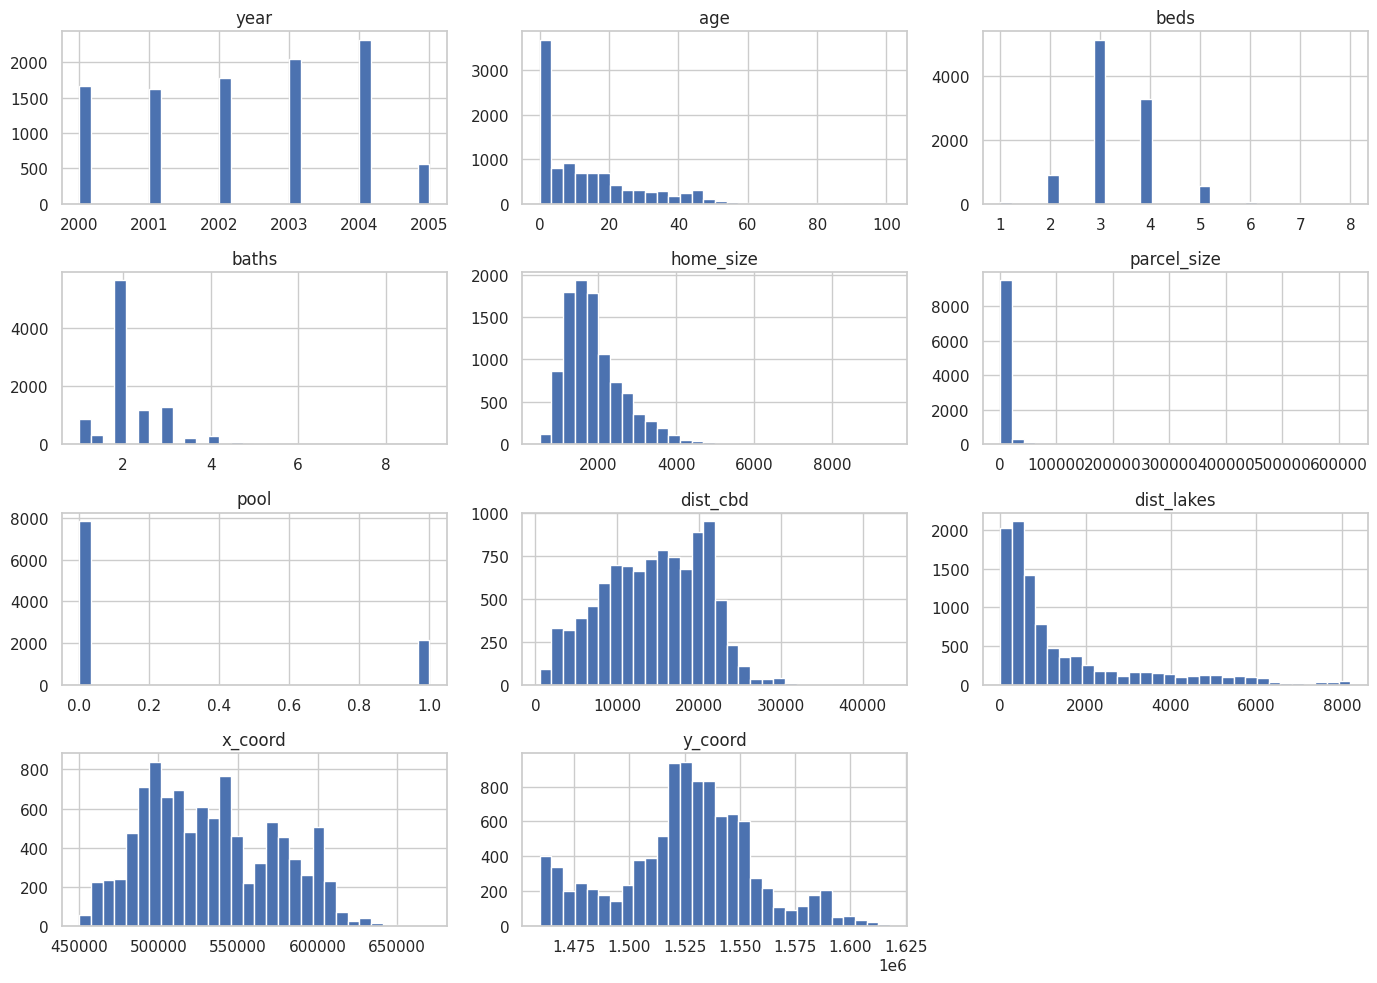

In [4]:
feature_cols = [c for c in config.FEATURES if c != config.TARGET]
df[feature_cols].hist(bins=30, figsize=(14, 10))
plt.tight_layout(); plt.show()

## Correlations

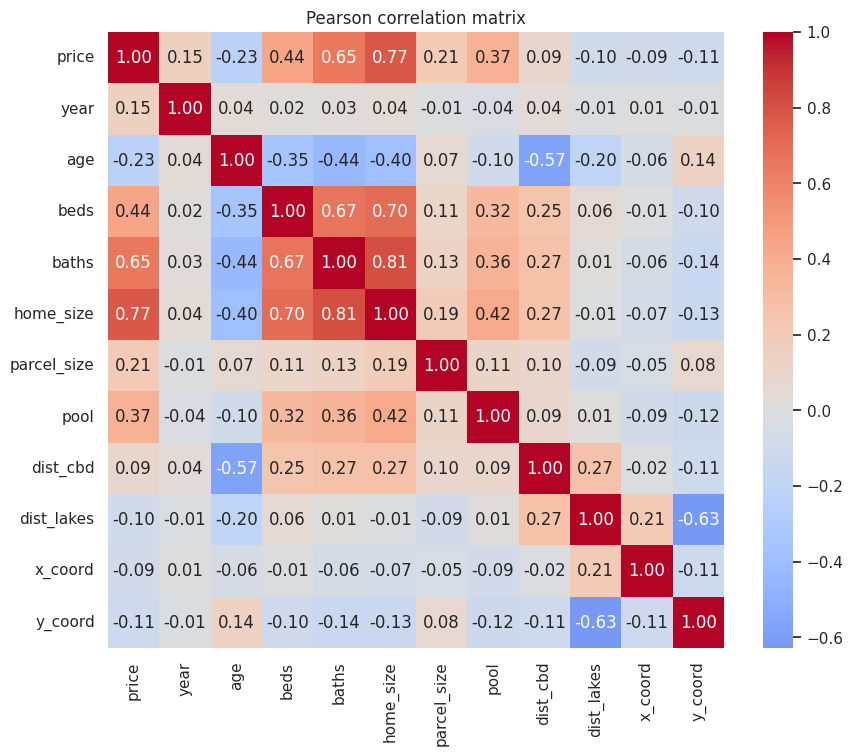

correlation with target (abs-sorted):
home_size      0.773845
baths          0.654125
beds           0.438886
pool           0.368448
age           -0.233054
parcel_size    0.206314
year           0.153009
y_coord       -0.109806
dist_lakes    -0.099388
x_coord       -0.090488
dist_cbd       0.087497
Name: price, dtype: float64


In [5]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Pearson correlation matrix")
plt.show()

ranked = (
    corr[config.TARGET]
    .drop(config.TARGET)
    .sort_values(key=lambda s: s.abs(), ascending=False)
)
print("correlation with target (abs-sorted):")
print(ranked)

## Top-correlated feature scatterplots

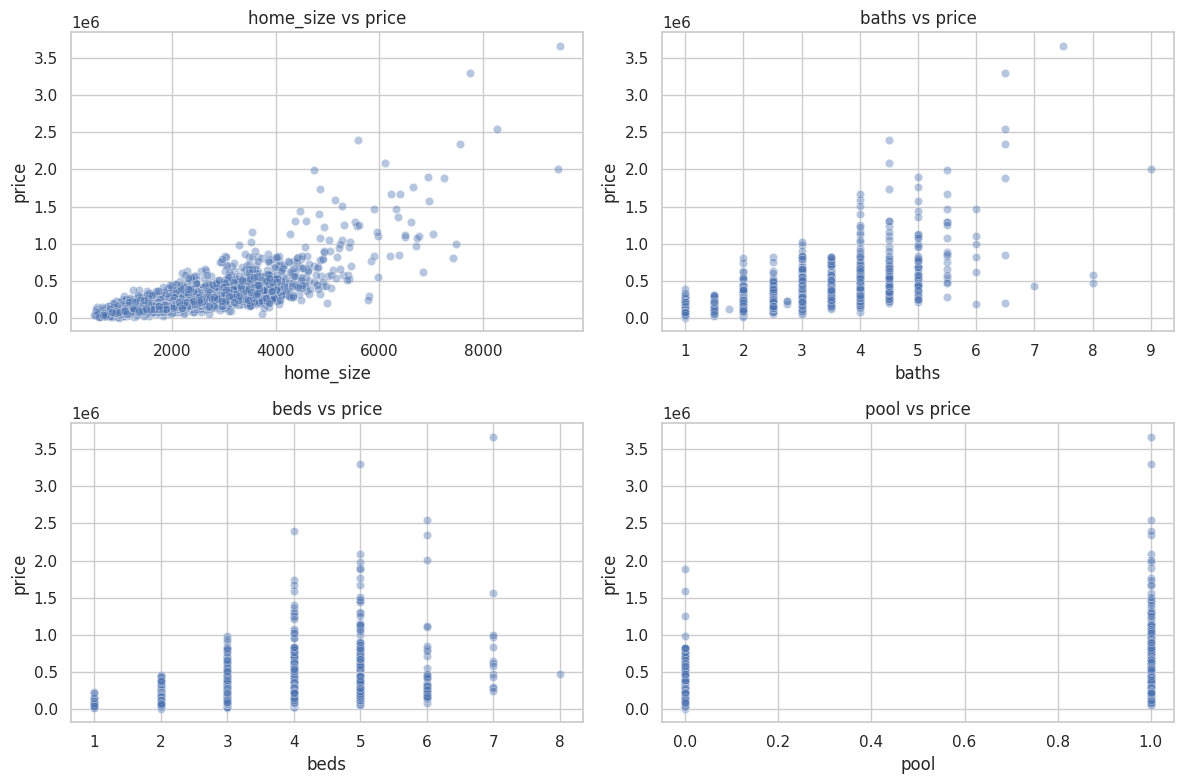

In [6]:
top4 = ranked.abs().head(4).index
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), top4):
    sns.scatterplot(x=df[col], y=df[config.TARGET], alpha=0.4, ax=ax)
    ax.set_title(f"{col} vs {config.TARGET}")
plt.tight_layout(); plt.show()